In [ ]:
"""Imports."""

import cv2
import numpy as np
import pandas as pd
import scipy.ndimage as ndimage
import torch
from matplotlib import pyplot as plt
from scipy.io import savemat
from sklearn import linear_model as sklearn_linear_model

%matplotlib inline

In [153]:
"""EyelinkReader class."""


def normalize_eye(eye):
    eye = (eye - 100) / 1000
    norm_eye = eye
    return norm_eye


def transform_between_eyes(eye_source, eye_target):
    keep_inds = np.logical_and(
        np.any(np.isfinite(eye_source), axis=1),
        np.any(np.isfinite(eye_target), axis=1),
    )

    keep_eye_source = eye_source[keep_inds]
    keep_eye_target = eye_target[keep_inds]

    reg = sklearn_linear_model.LinearRegression()
    reg.fit(keep_eye_source, keep_eye_target)
    pred_eye_target = reg.intercept_ + np.dot(eye_source, reg.coef_)

    return reg, pred_eye_target


class EyelinkReader:
    COLUMN_NAMES = [
        "time",
        "left_x",
        "left_y",
        "left_pupil",
        "right_x",
        "right_y",
        "right_pupil",
    ]

    def __init__(self, eyelink_file_path, exclude_nan=True):
        self.eyelink_file_path = eyelink_file_path
        self.name = eyelink_file_path.split("/")[-1].split(".")[0]
        self._exclude_nan = exclude_nan
        self.dataframe = self()

    def _process_string(self, s):
        if s == ".":
            return np.nan
        else:
            return float(s)

    def __call__(self):
        """Return dataframe."""

        # Read EyeLink asc file
        print("Reading file %s..." % self.eyelink_file_path)
        f = open(self.eyelink_file_path, "r")
        file_text = f.read().splitlines(True)
        file_text = list(filter(None, file_text))
        file_text = np.array(file_text)
        f.close()

        # Find lines with data samples
        print("Finding lines with data samples")
        sample_lines = []
        for i, text in enumerate(file_text):
            if text != "\n" and text.split()[0][0].isdigit():
                sample_lines.append(i)

        # Create dataframe
        print("Creating dataframe")
        start_line = sample_lines[0]
        end_line = sample_lines[-1]
        dataframe = pd.read_csv(
            self.eyelink_file_path,
            skiprows=start_line,
            nrows=end_line - start_line,
            delim_whitespace=True,
            index_col=False,
            names=EyelinkReader.COLUMN_NAMES,
            usecols=range(7),
        )

        for column in dataframe.columns:
            dataframe[column] = [
                self._process_string(x) for x in dataframe[column].tolist()
            ]

        start_time = dataframe["time"].tolist()[0]
        dataframe["time"] = (dataframe["time"] - start_time) / 1000.0

        time = dataframe["time"]
        print(f"Start time: {np.min(time)}")
        print(f"End time: {np.max(time)}")

        return dataframe

    def get_eye_pos(self, sample_rate_ms=2.0):
        # Check sample rate
        df_time = np.array(self.dataframe["time"])
        delta_df_time = df_time[1:] - df_time[:-1]
        if not np.allclose(delta_df_time, sample_rate_ms / 1000, atol=0.0001):
            raise ValueError(f"Sample rate is not always {sample_rate_ms}")

        # Get eye position and velocities
        left_eye = np.stack(
            [self.dataframe["left_x"], self.dataframe["left_y"]],
            axis=1,
        )
        right_eye = np.stack(
            [self.dataframe["right_x"], self.dataframe["right_y"]],
            axis=1,
        )

        if self._exclude_nan:
            bad_inds = np.logical_or(
                np.any(np.isnan(left_eye), axis=1),
                np.any(np.isnan(right_eye), axis=1),
            )
            left_eye[bad_inds] = np.nan
            right_eye[bad_inds] = np.nan

        left_eye = normalize_eye(left_eye)
        right_eye = normalize_eye(right_eye)

        return left_eye, right_eye

    def get_time_and_position(self):
        left_eye, right_eye = self._get_eye_pos()
        t = np.array(self.dataframe["time"])
        return t, left_eye, right_eye

    def get_smooth_eye_pos(self, kernel_size_ms, sample_rate_ms=2.0):
        # Get eye velocities
        left_eye, right_eye = self.get_eye_pos(sample_rate_ms=sample_rate_ms)

        # Get kernel
        kernel_size = int(kernel_size_ms // sample_rate_ms)
        linspace = np.linspace(0, 1, kernel_size)
        kernel = np.concatenate([linspace[:-1], linspace[::-1]])
        kernel /= np.sum(kernel)

        # Smooth eye position
        smooth_left = np.stack(
            [
                np.convolve(left_eye[:, i], kernel, mode="same")
                for i in range(2)
            ],
            axis=1,
        )
        smooth_right = np.stack(
            [
                np.convolve(right_eye[:, i], kernel, mode="same")
                for i in range(2)
            ],
            axis=1,
        )

        return smooth_left, smooth_right

    def get_smooth_eye_vel(self, kernel_size_ms, sample_rate_ms=2.0):
        # Get eye velocities
        left_eye, right_eye = self.get_eye_pos()
        left_v = left_eye[1:] - left_eye[:-1]
        right_v = right_eye[1:] - right_eye[:-1]

        # Get kernel
        kernel_size = int(kernel_size_ms // sample_rate_ms)
        linspace = np.linspace(0, 1, kernel_size)
        kernel = np.concatenate([linspace[:-1], linspace[::-1]])
        kernel /= np.sum(kernel)

        # Smooth and norm eye velocities
        smooth_left_v = np.stack(
            [np.convolve(left_v[:, i], kernel, mode="same") for i in range(2)],
            axis=1,
        )
        smooth_right_v = np.stack(
            [
                np.convolve(right_v[:, i], kernel, mode="same")
                for i in range(2)
            ],
            axis=1,
        )
        smooth_left_vel = np.linalg.norm(smooth_left_v, axis=1)
        smooth_right_vel = np.linalg.norm(smooth_right_v, axis=1)

        return smooth_right_vel, smooth_left_vel


def get_pursuit_state(eyelink_reader):
    # Get pursuit state
    pursuit_intervals = PURSUIT_INTERVALS[eyelink_reader.name]
    pursuit_state = np.nan * np.ones(len(eyelink_reader.dataframe["time"]))
    for interval in pursuit_intervals:
        pursuit_state[int(500 * interval[0]) : int(500 * interval[1])] = 2.5
    return pursuit_state


def plot_eye_vel(eyelink_reader, seconds_per_subplot=10):
    # Get eye data and pursuit state
    left_eye, right_eye = eyelink_reader.get_eye_pos()
    left_vel, right_vel = eyelink_reader.get_smooth_eye_vel(kernel_size_ms=30)
    t = np.array(eyelink_reader.dataframe["time"])
    t_start = t[0]
    pursuit_state = get_pursuit_state(eyelink_reader)

    # Plot
    num_subplots = int(np.ceil((t[-1] - t_start) / seconds_per_subplot))
    fig, axes = plt.subplots(num_subplots, 1, figsize=(8, 3 * num_subplots))
    for i, ax in enumerate(axes):
        start_ind = i * seconds_per_subplot * 500
        end_ind = (i + 1) * seconds_per_subplot * 500
        ax.plot(t[start_ind:end_ind], left_eye[start_ind:end_ind], c="b")
        ax.plot(t[start_ind:end_ind], right_eye[start_ind:end_ind], c="r")
        ax.scatter(
            t[start_ind:end_ind],
            pursuit_state[start_ind:end_ind],
            c="gray",
            s=10,
        )

In [154]:
# _CALIBRATION_FILENAMES = ['l_d5_t1', 'l_d5_t2']
_CALIBRATION_FILENAMES = ["l_d6_t5"]

_CALIBRATION_EYELINK_FILES = [
    f"data/eyelink_files/{x}.asc" for x in _CALIBRATION_FILENAMES
]
_CALIBRATION_OPTITRACK_FILES = [
    f"data/optitrack_files/{x}.csv" for x in _CALIBRATION_FILENAMES
]
_CALIBRATION_VIDEO_FILES = [
    f"data/reference_camera/{x}.avi" for x in _CALIBRATION_FILENAMES
]

eyelink_readers = [EyelinkReader(x) for x in _CALIBRATION_EYELINK_FILES]

Reading file ../lalo_day_6/eyelink_files/l_d6_t5.asc...
Finding lines with data samples
Creating dataframe
Start time: 0.0
End time: 213.59


In [ ]:
"""Pursuit intervals."""

PURSUIT_INTERVALS = {
    "l_d5_t1": [
        (4.0, 5.0),
        (5.9, 6.2),
        (8.0, 8.3),
        (11.5, 12.4),
        (20.0, 20.6),
    ],
    "l_d5_t2": [
        (3.4, 4.1),
        (4.4, 5.4),
        (7.5, 7.8),
        (8.1, 8.4),
        (12.5, 13.1),
        (17.45, 17.75),
        (31.4, 31.7),
        (32.95, 33.2),
        (38.4, 38.8),
        (71.6, 71.85),
        (72.7, 73.0),
        (75.6, 76.0),
        (86.4, 86.7),
        (106.8, 107.2),
        (113.7, 114.2),
        (132.7, 133.1),
    ],
    "l_d3_t2": [
        (7.5, 9.5),
        (14.5, 15.2),
        (21, 21.9),
        (40, 41.5),
        (10.2, 11.5),
        (23.8, 24.1),
        (28.6, 28.9),
        (34.3, 34.7),
        (47.6, 48.1),
        (54.6, 55.2),
    ],
    "l_d6_t5": [
        (16.5, 17.1),
        # (21.5, 21.8),
        # (27.9, 28.2),
        (28.8, 29.3),
        # (29.6, 30.0),
        (37.4, 37.7),
        (40.4, 40.7),
        # # (41.1, 41.4),
        # (48.2, 49.8),
        # # (50.3, 52.3),
        # (54.1, 54.6),
        (60.9, 62.0),
        (69.3, 70.5),
        # (71.2, 71.5),
        # (82.3, 85.0),
        # (87.1, 88.0),
        # (90.5, 91.2),
        # # (93.5, 93.9),
        # (99.0, 99.9),
        # (109.7, 110.1),
        # (127.2, 128.1),
        # (137.3, 137.9),
        # (139.6, 140.1),
        # # (141.3, 141.7),
        (149.6, 150.1),
        (151.4, 151.9),
        (177.3, 178.0),
        (180.4, 181.2),
        # (181.8, 182.3),
        (194.6, 195.0),
        (199.9, 200.3),
    ],
}

for eyelink_reader in eyelink_readers:
    plot_eye_vel(eyelink_reader)

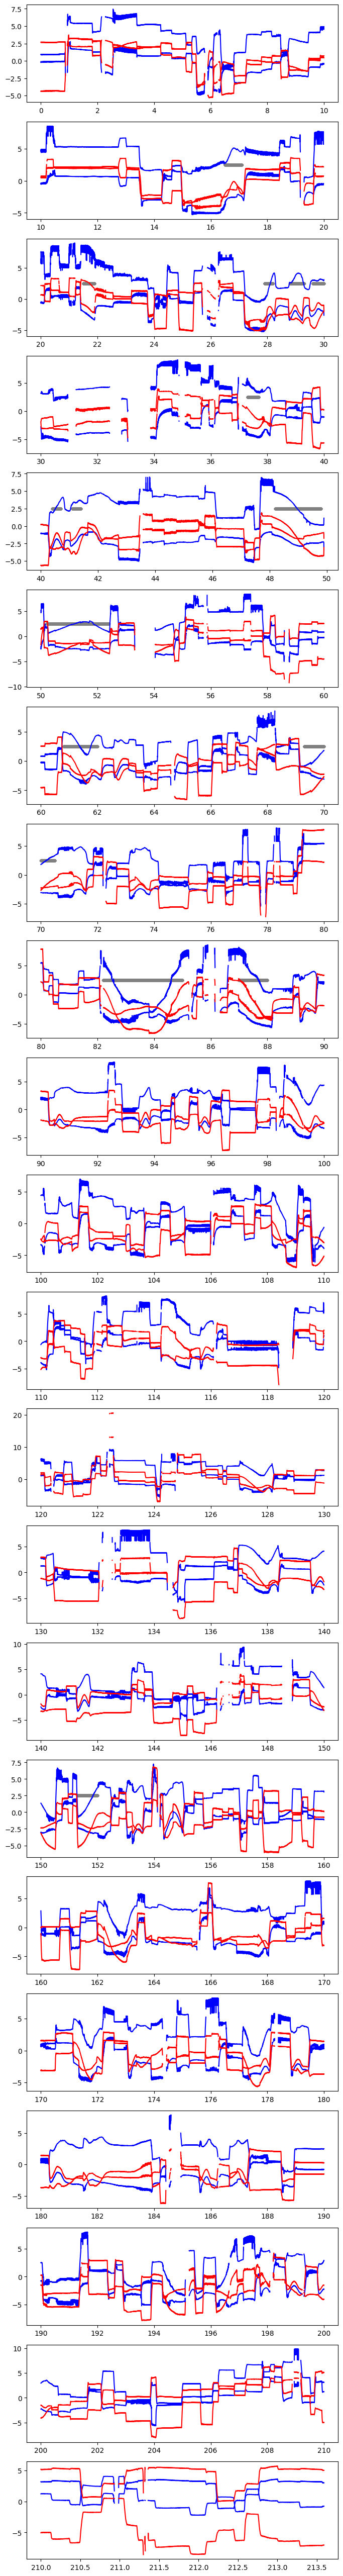

In [216]:
"""Pursuit intervals."""

PURSUIT_INTERVALS = {
    "l_d5_t1": [
        (4.0, 5.0),
        (5.9, 6.2),
        (8.0, 8.3),
        (11.5, 12.4),
        (20.0, 20.6),
    ],
    "l_d5_t2": [
        (3.4, 4.1),
        (4.4, 5.4),
        (7.5, 7.8),
        (8.1, 8.4),
        (12.5, 13.1),
        (17.45, 17.75),
        (31.4, 31.7),
        (32.95, 33.2),
        (38.4, 38.8),
        (71.6, 71.85),
        (72.7, 73.0),
        (75.6, 76.0),
        (86.4, 86.7),
        (106.8, 107.2),
        (113.7, 114.2),
        (132.7, 133.1),
    ],
    "l_d3_t2": [
        (7.5, 9.5),
        (14.5, 15.2),
        (21, 21.9),
        (40, 41.5),
        (10.2, 11.5),
        (23.8, 24.1),
        (28.6, 28.9),
        (34.3, 34.7),
        (47.6, 48.1),
        (54.6, 55.2),
    ],
    "l_d6_t5": [
        (16.5, 17.1),
        (21.5, 21.9),
        (27.9, 28.2),
        (28.8, 29.3),
        (29.6, 30.0),
        (37.3, 37.7),
        (40.4, 40.7),
        (41.1, 41.4),
        (48.2, 49.8),
        (50.2, 52.4),
        (60.8, 62.0),
        (69.3, 70.5),
        (82.2, 85.0),
        (87.0, 88.0),
        (151.3, 152.0),
    ],
}

for eyelink_reader in eyelink_readers:
    plot_eye_vel(eyelink_reader)

Reading file ../lalo_day_6/optitrack_files/l_d6_t5.csv...
Finding lines with data samples
Creating dataframe
Start time: 0.0
End time: 213.608333


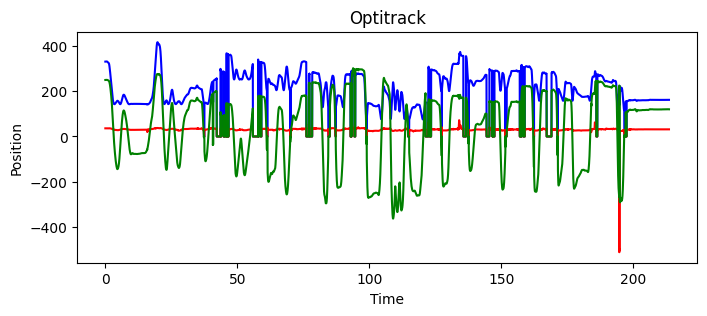

In [170]:
"""OptitrackReader class."""


class OptitrackReader:
    COLUMN_NAMES = [
        "time",
        # 't_x',
        # 't_y',
        # 't_z',
        "x",
        "y",
        "z",
    ]

    def __init__(self, optitrack_filename):
        self.optitrack_filename = optitrack_filename
        if "l_d5_t2" in optitrack_filename:
            self._usecols = (1, 5, 6, 7)
        else:
            self._usecols = (1, 2, 3, 4)
        self.dataframe = self()

    def _process_string(self, s):
        if s == ".":
            return np.nan
        else:
            return float(s)

    def __call__(self):
        """Return dataframe."""

        # Read optitrack file
        print("Reading file %s..." % self.optitrack_filename)
        f = open(self.optitrack_filename, "r")
        file_text = f.read().splitlines(True)
        file_text = list(filter(None, file_text))
        file_text = np.array(file_text)
        f.close()

        # Find lines with data samples
        print("Finding lines with data samples")
        sample_lines = []
        for i, text in enumerate(file_text):
            if text != "\n" and text.split()[0][0].isdigit():
                sample_lines.append(i)

        # Create dataframe
        print("Creating dataframe")

        start_line = sample_lines[0]
        end_line = sample_lines[-1]
        dataframe = pd.read_csv(
            self.optitrack_filename,
            sep=",",
            skiprows=start_line,
            nrows=end_line - start_line,
            index_col=False,
            names=OptitrackReader.COLUMN_NAMES,
            usecols=self._usecols,
        )

        for column in dataframe.columns:
            dataframe[column] = [
                self._process_string(x) for x in dataframe[column].tolist()
            ]

        time = dataframe["time"]
        print(f"Start time: {np.min(time)}")
        print(f"End time: {np.max(time)}")

        return dataframe

    def get_time_and_position(self):
        x = np.array(self.dataframe["x"])
        y = np.array(self.dataframe["y"])
        z = np.array(self.dataframe["z"])
        t = np.array(self.dataframe["time"])
        position = np.stack([x, y, z], axis=1)
        return t, position

    def set_video_coordinates(self, video_marker_pos):
        self.dataframe["video_x"] = list(video_marker_pos[:, 1])
        self.dataframe["video_y"] = list(video_marker_pos[:, 0])

    def get_time_and_position_video(self):
        x = np.array(self.dataframe["video_x"])
        y = np.array(self.dataframe["video_y"])
        t = np.array(self.dataframe["time"])
        position = np.stack([x, y], axis=1)
        return t, position

    def plot(self, time_range=None, sample_rate_ms=8.33333333):
        if time_range is None:
            time_range = (
                np.min(self.dataframe["time"]),
                np.max(self.dataframe["time"]),
            )

        index_range = [
            int(1000 * time_range[0] / sample_rate_ms),
            int(1000 * time_range[1] / sample_rate_ms),
        ]

        t, position = self.get_time_and_position()
        t = t[index_range[0] : index_range[1]]
        position = position[index_range[0] : index_range[1]]
        position[np.isnan(position)] = 0.0

        fig, ax = plt.subplots(1, 1, figsize=(8, 3))
        ax.plot(t, position[:, 0], c="b")
        ax.plot(t, position[:, 1], c="r")
        ax.plot(t, position[:, 2], c="g")
        ax.set_ylabel("Position")
        ax.set_xlabel("Time")
        ax.set_title("Optitrack")


optitrack_readers = [OptitrackReader(x) for x in _CALIBRATION_OPTITRACK_FILES]
for optitrack_reader in optitrack_readers:
    optitrack_reader.plot()

In [174]:
"""Transform optitrack to reference camera coordinate system."""


def _extract_marker(frame):
    return np.prod(frame > 250, axis=2)


def _brightest_spot(image, sigma=10):
    smooth_image = ndimage.gaussian_filter(
        image, sigma=(sigma, sigma), order=0
    )
    indices = np.unravel_index(smooth_image.argmax(), smooth_image.shape)
    return indices


def _extract_marker_trajectory(frames):
    markers = np.array([_extract_marker(f) for f in frames])
    trajectory = np.sum(markers, axis=0)
    common = trajectory > 10
    trajectory[common] = 0
    for i in range(len(frames)):
        markers[i, common] = 0
    brightest_spots = np.array(
        [_brightest_spot(x.astype(float)) for x in markers]
    )
    return brightest_spots, trajectory.astype(bool)


def get_video_transform(video_file, optitrack_reader, video_range=(400, 450)):
    cap = cv2.VideoCapture(video_file)
    num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    print(f"num_frames = {num_frames}")

    frames = []
    frame_num = 0
    while cap.isOpened() and frame_num < video_range[1]:
        frame_num += 1
        ret, frame = cap.read()
        if frame_num > video_range[0]:
            frames.append(frame)

    # Extract marker

    brightest_spots, trajectory = _extract_marker_trajectory(frames)

    fig, axes = plt.subplots(1, 4, figsize=(12, 3))
    axes[0].imshow(trajectory)
    axes[1].scatter(brightest_spots[:, 0], brightest_spots[:, 1])

    # Regress marker position to image position
    marker_x = np.array(optitrack_reader.dataframe["x"])
    marker_y = np.array(optitrack_reader.dataframe["y"])
    marker_z = np.array(optitrack_reader.dataframe["z"])

    marker_pos = np.stack([marker_x, marker_y, marker_z], axis=1)
    segment_marker_pos = marker_pos[video_range[0] : video_range[1]]

    video_reg = sklearn_linear_model.LinearRegression()
    video_reg.fit(segment_marker_pos, brightest_spots)
    video_markers = video_reg.predict(segment_marker_pos)
    video_markers = np.round(video_markers).astype(int)

    traj = np.copy(trajectory).astype(float)
    for x in video_markers:
        traj[x[0], x[1]] = 2
    axes[2].imshow(traj)

    axes[3].imshow(frames[0])
    axes[3].scatter(video_markers[0][1], video_markers[0][0], s=100)

    return video_reg


# Get video transform
video_reg = get_video_transform(
    _CALIBRATION_VIDEO_FILES[1], optitrack_readers[1]
)

# Apply regressor to optitrack marker position for all optitrack readers
for optitrack_reader in optitrack_readers:
    marker_x = np.array(optitrack_reader.dataframe["x"])
    marker_y = np.array(optitrack_reader.dataframe["y"])
    marker_z = np.array(optitrack_reader.dataframe["z"])
    marker_pos = np.stack([marker_x, marker_y, marker_z], axis=1)
    video_marker_pos = video_reg.intercept_[None] + np.dot(
        marker_pos, video_reg.coef_.T
    )

    # Add video marker position to optitrack_reader
    optitrack_reader.set_video_coordinates(video_marker_pos)

print("Finished")

Finished


In [193]:
"""Create data for training."""


def get_data(eyelink_reader, optitrack_reader):
    # Get eye data
    t_e = np.array(eyelink_reader.dataframe["time"])
    left_eye, right_eye = eyelink_reader.get_smooth_eye_pos(kernel_size_ms=10)
    pos_e = np.concatenate([left_eye, right_eye], axis=1)
    # pos_e = right_eye
    print(f"Eye range: [{np.min(t_e)}, {np.max(t_e)}]")

    # Get object data
    t_o, pos_o = optitrack_reader.get_time_and_position_video()
    print(f"Optitrack range: [{np.min(t_o)}, {np.max(t_o)}]")

    # Get pursuit state
    pursuit_state = get_pursuit_state(eyelink_reader)

    # Resample eye data
    t_o_freq = 1.0 / 120
    t_e_freq = 1.0 / 500
    eye_sub_inds = np.round(np.arange(0, t_e[-1], t_o_freq) / t_e_freq)
    eye_sub_inds = eye_sub_inds.astype(int)
    t_e = t_e[eye_sub_inds]
    pos_e = pos_e[eye_sub_inds]
    pursuit_state = pursuit_state[eye_sub_inds]
    min_length = min(len(t_e), len(t_o))
    t_o = t_o[:min_length]
    t_e = t_e[:min_length]
    pos_o = pos_o[:min_length]
    pos_e = pos_e[:min_length]
    pursuit_state = pursuit_state[:min_length]

    # Subsample only pursuit indices
    pursuit_inds = np.isfinite(pursuit_state)
    t_e = t_e[pursuit_inds]
    pos_e = pos_e[pursuit_inds]
    t_o = t_o[pursuit_inds]
    pos_o = pos_o[pursuit_inds]

    # Subsample only good indices
    keep_inds = np.all(np.isfinite(pos_e), axis=1) * np.all(
        np.isfinite(pos_o), axis=1
    )
    t_e = t_e[keep_inds]
    pos_e = pos_e[keep_inds]
    t_o = t_o[keep_inds]
    pos_o = pos_o[keep_inds]

    return t_e, pos_e, t_o, pos_o


class Trainer:
    def __init__(
        self,
        model,
        eyelink_readers,
        optitrack_readers,
        batch_size=32,
        lr=0.001,
        training_steps=100,
        optimizer=torch.optim.RMSprop,
        grad_clip=1,
    ):
        self._model = model
        self._training_steps = training_steps
        self._batch_size = batch_size
        self._lr = lr
        self._optimizer = optimizer
        self._grad_clip = grad_clip

        self._scalar_eval_every = self._training_steps // 10
        self._optimizer = self._optimizer(model.parameters(), lr=self._lr)

        # Get data tensors
        all_pos_e = []
        all_pos_o = []
        for eyelink_reader, optitrack_reader in zip(
            eyelink_readers, optitrack_readers
        ):
            _, pos_e, _, pos_o = get_data(eyelink_reader, optitrack_reader)
            all_pos_e.append(pos_e.astype(np.float32))
            all_pos_o.append(pos_o.astype(np.float32))
        self._inputs = np.concatenate(all_pos_e, axis=0)
        self._outputs = np.concatenate(all_pos_o, axis=0)
        self._n_samples = pos_e.shape[0]

    def _get_batch(self):
        indices = np.random.choice(self._n_samples, size=(self._batch_size))
        batch_inputs = torch.from_numpy(self._inputs[indices])
        batch_outputs = torch.from_numpy(self._outputs[indices])
        return batch_inputs, batch_outputs

    def __call__(self):
        """Evaluate model on dataset."""
        print("\nBeginning training")
        training_losses = []
        for step in range(self._training_steps):
            batch_inputs, batch_outputs = self._get_batch()
            self._optimizer.zero_grad()
            loss = self._model.loss(batch_inputs, batch_outputs)
            loss.backward()

            if self._grad_clip is not None:
                torch.nn.utils.clip_grad_norm_(
                    self._model.parameters(), self._grad_clip
                )
            self._optimizer.step()
            training_losses.append(float(loss.detach()))

            if step % self._scalar_eval_every == 0:
                print(
                    f"    step {step} / {self._training_steps}: Loss = "
                    f"{training_losses[-1]}"
                )

        return self._model, training_losses

    def eval(self, inputs=None):
        if inputs is None:
            inputs = torch.from_numpy(self._inputs)
        pred_outputs = self._model(inputs).detach().numpy()
        return self._outputs, pred_outputs

In [194]:
"""MLP model class."""


class MLPModel(torch.nn.Module):
    """MLP model."""

    def __init__(
        self,
        in_features,
        layer_features,
        activation=None,
        bias=True,
        activate_final=False,
    ):
        """Create MLP module.
        Args:
            in_features: Number of features of the input.
            layer_features: Iterable of ints. Output sizes of the layers.
            activation: Activation function. If None, defaults to ReLU.
            bias: Bool. Whether to use bias.
            activate_final: Bool. Whether to apply activation function to the
                final output.
        """
        super(MLPModel, self).__init__()

        self._in_features = in_features
        self._layer_features = layer_features
        self.bias = bias

        if activation is None:
            activation = torch.nn.ReLU()
        self.activation = activation

        features_list = [in_features] + list(layer_features)
        module_list = []
        for i in range(len(features_list) - 1):
            if i > 0:
                module_list.append(activation)
            layer = torch.nn.Linear(
                in_features=features_list[i],
                out_features=features_list[i + 1],
                bias=bias,
            )
            module_list.append(layer)

        if activate_final:
            module_list.append(activation)

        self.net = torch.nn.Sequential(*module_list)

    def forward(self, x):
        """Apply MLP to input."""
        return self.net(x)

    def loss(self, inputs, outputs):
        pred = self.forward(inputs)
        loss = torch.mean(torch.square(pred - outputs))
        return loss

    @property
    def in_features(self):
        return self._in_features

    @property
    def layer_features(self):
        return self._layer_features

    @property
    def out_features(self):
        return self._layer_features[-1]

Eye range: [0.0, 213.59]
Optitrack range: [0.0, 213.608333]

Beginning training
    step 0 / 10000: Loss = 564190.1875
    step 1000 / 10000: Loss = 15054.1279296875
    step 2000 / 10000: Loss = 10895.669921875
    step 3000 / 10000: Loss = 12113.5498046875
    step 4000 / 10000: Loss = 10417.53125
    step 5000 / 10000: Loss = 9220.16796875
    step 6000 / 10000: Loss = 17306.8515625
    step 7000 / 10000: Loss = 14891.9013671875
    step 8000 / 10000: Loss = 8170.6630859375
    step 9000 / 10000: Loss = 6470.4140625


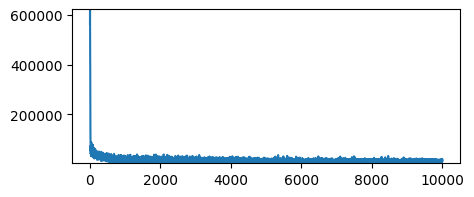

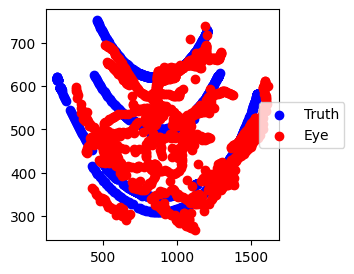

In [217]:
"""Run evaluation."""

# Create model
model = MLPModel(
    in_features=4,
    layer_features=(128, 32, 2),
)

# Create trainer
trainer = Trainer(
    model=model,
    eyelink_readers=eyelink_readers,
    optitrack_readers=optitrack_readers,
    lr=0.005,
    training_steps=10000,
)

# Run training loop
_, losses = trainer()

# Plot losses
fig, ax = plt.subplots(figsize=(5, 2))
ax.plot(losses)
ax.set_ylim([min(losses), max(losses)])

# Plot results
outputs, pred_outputs = trainer.eval()
fig, ax = plt.subplots(1, 1, figsize=(3, 3))
ax.scatter(outputs[:, 0], outputs[:, 1], c="b", label="Truth")
ax.scatter(pred_outputs[:, 0], pred_outputs[:, 1], c="r", label="Eye")
ax.legend(loc="center", bbox_to_anchor=(1.1, 0.5))

In [478]:
"""Apply to new video."""


def get_data_eyelink(eyelink_reader):
    # Get eye data
    t_e = np.array(eyelink_reader.dataframe["time"])
    left_eye, right_eye = eyelink_reader.get_smooth_eye_pos(kernel_size_ms=10)
    pos_e = np.concatenate([left_eye, right_eye], axis=1)
    # pos_e = right_eye
    print(f"Eye range: [{np.min(t_e)}, {np.max(t_e)}]")

    # Resample eye data
    t_o_freq = 1.0 / 120
    t_e_freq = 1.0 / 500
    eye_sub_inds = np.round(np.arange(0, t_e[-1], t_o_freq) / t_e_freq)
    eye_sub_inds = eye_sub_inds.astype(int)
    t_e = t_e[eye_sub_inds]
    pos_e = pos_e[eye_sub_inds]

    return t_e, pos_e


eyelink_file_ref = "../lalo_day_6/eyelink_files/l_d6_t6.asc"
ref_video_filename = "t6_60820"
video_file_ref = f"../lalo_day_6/reference_camera/{ref_video_filename}.avi"

eyelink_reader_ref = EyelinkReader(eyelink_file_ref, exclude_nan=False)

inputs_ref = get_data_eyelink(eyelink_reader_ref)[1].astype(np.float32)
pred_eye_ref = trainer.eval(torch.from_numpy(inputs_ref))[1]


# Load video
_TRIAL_START = int(ref_video_filename.split("_")[1])

cap = cv2.VideoCapture(video_file_ref)
num_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
print(f"num_frames = {num_frames}")
trial_frames = []
# cap.set(cv2.CAP_PROP_FRAME_COUNT, _TRIAL_START - 1)
cap.set(cv2.CAP_PROP_FRAME_COUNT, -1)
for _ in range(num_frames):
    ret, frame = cap.read()
    trial_frames.append(np.copy(frame))

Reading file ../lalo_day_6/eyelink_files/l_d6_t6.asc...
Finding lines with data samples
Creating dataframe
Start time: 0.0
End time: 645.988
Eye range: [0.0, 645.988]
num_frames = 365


matlab_filename: videos/matlab/t6_60820.mat


/var/folders/39/y4130jp93gx8kmc6bw85pr1r0000gn/T/ipykernel_32388/3576069170.py:10: RuntimeWarning: invalid value encountered in cast
  trial_eye = np.round(trial_eye).astype(int)


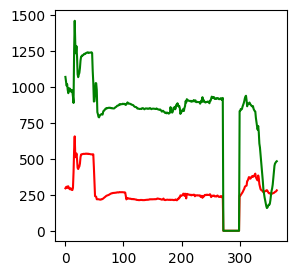

In [480]:
"""Same matlab file with video."""

matlab_filename = f"videos/matlab/{ref_video_filename}.mat"
print(f"matlab_filename: {matlab_filename}")

trial_eye = np.copy(pred_eye_ref[_TRIAL_START : _TRIAL_START + num_frames])
trial_eye = trial_eye[:, ::-1]
trial_eye = np.round(trial_eye).astype(int)
plus_sign = get_plus_sign(width=43)
plus_sign_trail = get_circle(width=15)
# sample_freq = 20
sample_freq = 1
video_frames = add_eye_patch(
    trial_frames[::sample_freq],
    trial_eye[::sample_freq],
    plus_sign_trail,
    plus_sign,
    startrail_length=25,
    # startrail_length=1,
)
video_frames = video_frames[::3]
savemat(matlab_filename, {"frames": np.array(video_frames)})

fig, ax = plt.subplots(figsize=(3, 3))
ax.plot(trial_eye[:, 0], c="r")
ax.plot(trial_eye[:, 1], c="g")

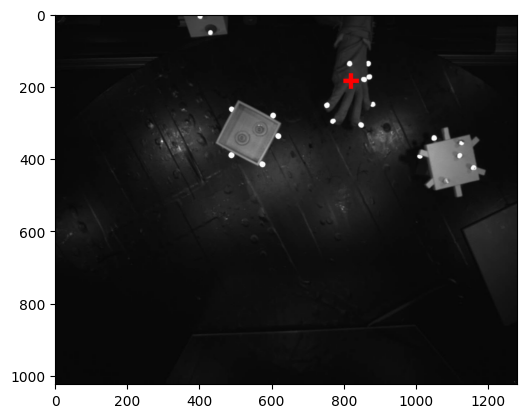

In [442]:
plt.figure()
plt.imshow(video_frames[10])

In [428]:
"""Eye plotting utils."""


def get_plus_sign(width=41, ratio=0.3):
    plus_sign = np.zeros((width, width))
    middle_index = width // 2
    half_width = int(np.round(ratio * middle_index))
    plus_sign[middle_index - half_width : middle_index + half_width] = 1
    plus_sign[:, middle_index - half_width : middle_index + half_width] = 1
    return plus_sign.astype(bool)


def get_circle(width=21):
    linspace = np.linspace(-1.0, 1.0, width)
    mesh = np.stack(np.meshgrid(linspace, linspace), axis=2)
    radii = np.linalg.norm(mesh, axis=2)
    circle = np.zeros((width, width))
    circle[radii < 1] = 1
    return circle.astype(bool)


def get_eye_patch_mask(image, patch, location):
    start_inds = location - np.array(patch.shape) // 2
    end_inds = start_inds + np.array(patch.shape)
    image_mask = np.zeros(
        (
            image.shape[0] + 2 * patch.shape[0],
            image.shape[1] + 2 * patch.shape[1],
        ),
        dtype=np.uint8,
    )
    n_start_inds = start_inds + np.array(patch.shape)
    n_end_inds = end_inds + np.array(patch.shape)
    out_of_frame = np.any(n_start_inds < 0) or np.any(
        n_end_inds > np.array(image_mask.shape)
    )
    if not out_of_frame:
        image_mask[
            n_start_inds[0] : n_end_inds[0], n_start_inds[1] : n_end_inds[1]
        ] = patch
    image_mask = image_mask[
        patch.shape[0] : patch.shape[0] + image.shape[0],
        patch.shape[1] : patch.shape[1] + image.shape[1],
    ]
    return image_mask.astype(float)


def get_eye_patch_masks(frames, patch, locations):
    masks = [
        get_eye_patch_mask(frame, patch, loc)
        for frame, loc in zip(frames, locations)
    ]
    return masks


def _blend(img_0, img_1, alpha):
    alpha = alpha[:, :, None]
    img = (alpha * img_0 + (1 - alpha) * img_1).astype(np.uint8)
    return img


def add_eye_patch(frames, locations, patch, patch_trail, startrail_length=20):
    eye_masks = get_eye_patch_masks(frames, patch, locations)
    eye_masks_trail = get_eye_patch_masks(frames, patch_trail, locations)

    alpha_per_mask = np.linspace(0.0, 0.3, startrail_length)[1:]
    alpha_per_mask = np.concatenate([alpha_per_mask, [1.0]])
    red_frame = np.zeros_like(frames[0], dtype=np.uint8)
    red_frame[:, :, 0] = 255
    video_frames = []
    for i in range(0, len(frames)):
        start_ind = max(0, i - startrail_length)
        masks = eye_masks[start_ind:i] + [eye_masks_trail[i]]
        current_m = np.zeros_like(masks[0])
        for alpha, m in zip(alpha_per_mask[::-1], masks[::-1]):
            current_m += (1 - current_m) * alpha * m
        new_frame = _blend(red_frame, frames[i], current_m)
        video_frames.append(new_frame)
    return video_frames